# Analysis of Macro Ecological and Economical factors on Infrastructure Distribution in the EU

**Team members:**
- Ricardo ZWEIN
- Ahmat ROUCHAD
- Chanez KHELIFA
- Amin RACHID
- Chems MITTA
---

## Dataset Description

This project investigates how physical geography (terrain difficulty and proximity to navigable water) alongside public investment budgets, explains the distribution of road and rail infrastructure across EU NUTS2 regions.

We combine five data sources, all joined on the NUTS2 regional classification:

| Source | Variable(s) | Type | Temporal coverage |
|---|---|---|---|
| Eurostat `tran_r_net` | Road + rail density (km/1000km²) | Time series | ~1990–2022 |
| Eurostat `tgs00024` | Population density | Time series | 1990–2023 |
| Eurostat `gov_10a_exp` | Regional public expenditure | Time series | 1995–2023 |
| NASA SRTM (via `elevation`) | Mean elevation + terrain slope | Static raster | 2000 snapshot |
| HydroSHEDS HydroRIVERS | Distance to nearest major river | Static vector | Current |

**Research question:** Do terrain difficulty, proximity to water, and public budget explain infrastructure density across EU regions and can past values predict future infrastructure levels?

**Dimensions:**
- *Temporal*: Eurostat time series (1995–2022)
- *Spatial*: NUTS2 polygons (~240 EU regions)
- *Analytical*: Infrastructure density as a function of geographic and fiscal variables

## 0. Installations

Run once per environment. Comment out after first run.

In [1]:
# !pip install -r requirements.txt --prefer-binary 

## 1. Imports

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Geospatial
import geopandas as gpd
from shapely.geometry import Point, mapping
import rasterio
import rasterio.merge
from rasterio.mask import mask as rio_mask
import fiona

# Eurostat API
import eurostat

# Visualisation
import matplotlib.pyplot as plt
import plotly.express as px

print("All imports OK")

All imports OK


## 2. Data Loading

> GenAI Note: This section has been written with the help of Generative AI, who has been prompted to join all datasets on NUTS2 region code and generate the topology based on those, too. We still do understand the code, but did not write it by hand. It was only one prompt, zero-shot with no examples. We also generated a notebook skeleton to help make presentation more readable quickly and focus on analysis.

Each function loads one data source and returns it in a clean, NUTS2-joinable format.

> **Note:** HydroRIVERS must be downloaded manually once and placed in `./data/`.
> - HydroRIVERS Europe: Should be in repo but just in case - https://www.hydrosheds.org/products/hydrorivers → download `HydroRIVERS_v10_eu.shp`
> - Terrain (Copernicus GLO-30) streams automatically from AWS S3 on first run, then cached to `./data/terrain_nuts2.csv` - should also be in repo

In [3]:
# ─────────────────────────────────────────────
# Function: load_nuts2
# Input:  resolution string (e.g. '20M'), year int (e.g. 2021)
# Output: GeoDataFrame of NUTS2 polygons with columns [NUTS_ID, geometry]
# ─────────────────────────────────────────────
def load_nuts2(resolution='20M', year=2021):
    url = (
        f"https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
        f"NUTS_RG_{resolution}_{year}_4326.geojson"
    )
    gdf = gpd.read_file(url)
    # Keep only NUTS level 2
    gdf = gdf[gdf['LEVL_CODE'] == 2][['NUTS_ID', 'NUTS_NAME', 'geometry']].copy()
    gdf = gdf.reset_index(drop=True)
    print(f"NUTS2 loaded: {len(gdf)} regions")
    return gdf

In [4]:
# ─────────────────────────────────────────────
# Function: load_infrastructure
# Input:  none
# Output: DataFrame with columns [NUTS_ID, year, motorway_density, rail_density]
#         density in km / 1000 km² of region area
# Source: Eurostat dataset tran_r_net
# ─────────────────────────────────────────────
def load_infrastructure():
    df = eurostat.get_data_df('tran_r_net')

    # tran_r_net has columns: freq, unit, vehicle, geo\TIME_PERIOD, then year columns
    # Melt from wide to long format
    id_vars = [c for c in df.columns if not str(c).isdigit() and '\\' not in str(c)]
    geo_col = [c for c in df.columns if '\\' in str(c)][0]

    df = df.rename(columns={geo_col: 'NUTS_ID'})
    year_cols = [c for c in df.columns if str(c).isdigit()]

    df_long = df.melt(
        id_vars=[c for c in df.columns if c not in year_cols],
        value_vars=year_cols,
        var_name='year',
        value_name='infra_km'
    )
    df_long['year'] = df_long['year'].astype(int)
    df_long['infra_km'] = pd.to_numeric(df_long['infra_km'], errors='coerce')

    # Keep only NUTS2 (4-character codes like FR10, DE21)
    df_long = df_long[df_long['NUTS_ID'].str.len() == 4]

    print(f"Infrastructure data: {df_long.shape[0]} rows, years {df_long['year'].min()}–{df_long['year'].max()}")
    return df_long

In [5]:
# ─────────────────────────────────────────────
# Function: load_population
# Input:  none
# Output: DataFrame with columns [NUTS_ID, year, pop_density]
#         pop_density in inhabitants / km²
# Source: Eurostat dataset tgs00024
# ─────────────────────────────────────────────
def load_population():
    df = eurostat.get_data_df('tgs00024')

    geo_col = [c for c in df.columns if '\\' in str(c)][0]
    df = df.rename(columns={geo_col: 'NUTS_ID'})
    year_cols = [c for c in df.columns if str(c).isdigit()]

    df_long = df.melt(
        id_vars=[c for c in df.columns if c not in year_cols],
        value_vars=year_cols,
        var_name='year',
        value_name='pop_density'
    )
    df_long['year'] = df_long['year'].astype(int)
    df_long['pop_density'] = pd.to_numeric(df_long['pop_density'], errors='coerce')
    df_long = df_long[df_long['NUTS_ID'].str.len() == 4]

    print(f"Population data: {df_long.shape[0]} rows, years {df_long['year'].min()}–{df_long['year'].max()}")
    return df_long

In [6]:
# ─────────────────────────────────────────────
# Function: load_budget
# Input:  none
# Output: DataFrame with columns [NUTS_ID, year, expenditure_mEUR]
# Source: Eurostat dataset gov_10a_exp (general government expenditure by function)
# Note:   We filter for transport infrastructure expenditure (COFOG code GF0452)
# ─────────────────────────────────────────────
def load_budget():
    df = eurostat.get_data_df('gov_10a_exp')

    geo_col = [c for c in df.columns if '\\' in str(c)][0]
    df = df.rename(columns={geo_col: 'NUTS_ID'})

    # Filter to transport expenditure if cofog column exists
    if 'cofog99' in df.columns:
        df = df[df['cofog99'].str.startswith('GF04', na=False)]

    year_cols = [c for c in df.columns if str(c).isdigit()]
    df_long = df.melt(
        id_vars=[c for c in df.columns if c not in year_cols],
        value_vars=year_cols,
        var_name='year',
        value_name='expenditure_mEUR'
    )
    df_long['year'] = df_long['year'].astype(int)
    df_long['expenditure_mEUR'] = pd.to_numeric(df_long['expenditure_mEUR'], errors='coerce')

    # This dataset is country-level (NUTS0 = 2-char codes), keep as-is
    # We will join on country prefix when merging with NUTS2
    df_long['country'] = df_long['NUTS_ID'].str[:2]

    print(f"Budget data: {df_long.shape[0]} rows, years {df_long['year'].min()}–{df_long['year'].max()}")
    return df_long

In [7]:
import os
import threading
import glob
from concurrent.futures import ThreadPoolExecutor, as_completed
from shapely.geometry import mapping

import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask as rio_mask
import s3fs

COP_DEM_BUCKET = "copernicus-dem-30m"
CHECKPOINT_INTERVAL = 30
CHECKPOINT_DIR = "./data/terrain_checkpoints"

# ---------------------------------------------------------------------------
# Module-level shared state
# ---------------------------------------------------------------------------

# Single rasterio Env shared across all threads — avoids per-tile context overhead
_RASTERIO_ENV = rasterio.Env(
    aws_unsigned=True,
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
    GDAL_HTTP_MERGE_CONSECUTIVE_RANGES="YES",
    GDAL_HTTP_MULTIPLEX="YES",
    GDAL_HTTP_VERSION=2,
)

# Shared S3 filesystem with connection pool — one pool reused across all threads
# max_pool_connections lives in botocore Config, not client_kwargs
_S3_FS = s3fs.S3FileSystem(anon=True, config_kwargs={"max_pool_connections": 64})

# Tile array cache: key = (lat, lon), value = np.ndarray or None (confirmed missing)
# Protected by a lock to prevent duplicate S3 downloads when threads race the same tile
_TILE_CACHE: dict = {}
_TILE_CACHE_LOCK = threading.Lock()


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------

def _tile_s3_key(lat: int, lon: int) -> str:
    """
    Build the S3 key for a Copernicus GLO-30 tile given its SW corner.

    Input:  lat (int), lon (int) — SW corner of 1°×1° tile
    Output: S3 key string
    """
    lat_str = f"{'N' if lat >= 0 else 'S'}{abs(lat):02d}"
    lon_str = f"{'E' if lon >= 0 else 'W'}{abs(lon):03d}"
    name = f"Copernicus_DSM_COG_10_{lat_str}_00_{lon_str}_00_DEM"
    return f"{name}/{name}.tif"


def _get_tiles_for_bounds(bounds: tuple) -> list:
    """
    Return list of (lat, lon) SW corners for all 1°×1° tiles overlapping bounds.

    Input:  bounds = (minx, miny, maxx, maxy) in EPSG:4326
    Output: list of (lat, lon) integer tuples
    """
    minx, miny, maxx, maxy = bounds
    tiles = []
    for lat in range(int(np.floor(miny)), int(np.ceil(maxy))):
        for lon in range(int(np.floor(minx)), int(np.ceil(maxx))):
            tiles.append((lat, lon))
    return tiles


def _fetch_tile_file(lat: int, lon: int):
    """
    Return an open rasterio DatasetReader for a GLO-30 tile via the shared S3
    connection pool. Caller is responsible for closing. Returns None if tile
    does not exist (ocean / missing coverage).

    Input:  lat (int), lon (int) — SW corner of 1°×1° tile
    Output: rasterio.DatasetReader or None
    """
    key = _tile_s3_key(lat, lon)
    s3_path = f"{COP_DEM_BUCKET}/{key}"
    try:
        with _RASTERIO_ENV:
            return rasterio.open(_S3_FS.open(s3_path))
    except Exception:
        return None


def _fetch_tile_cached(lat: int, lon: int) -> np.ndarray | None:
    """
    Fetch the full elevation array for one GLO-30 tile, using the module-level
    tile cache. Thread-safe: the lock prevents duplicate S3 downloads when
    multiple threads race on the same tile simultaneously.

    Input:  lat (int), lon (int) — SW corner of 1°×1° tile
    Output: np.ndarray of int16 elevation values (full tile), or None if missing
    """
    cache_key = (lat, lon)

    # Fast path — already resolved (hit or confirmed missing)
    with _TILE_CACHE_LOCK:
        if cache_key in _TILE_CACHE:
            return _TILE_CACHE[cache_key]

    # Slow path — fetch from S3 outside the lock so other threads aren't blocked
    result = None
    key = _tile_s3_key(lat, lon)
    s3_path = f"{COP_DEM_BUCKET}/{key}"
    try:
        with _RASTERIO_ENV:
            with rasterio.open(_S3_FS.open(s3_path)) as src:
                result = src.read(1)
    except Exception:
        result = None  # tile does not exist — store None to skip on future hits

    with _TILE_CACHE_LOCK:
        # Another thread may have populated the same key while we were fetching;
        # prefer theirs to avoid a redundant write, but store ours if still absent
        if cache_key not in _TILE_CACHE:
            _TILE_CACHE[cache_key] = result

    return _TILE_CACHE[cache_key]


def _process_region(row: tuple) -> dict:
    """
    Compute mean elevation and terrain roughness std for a single NUTS2 region.
    Tiles are fetched via the shared S3 connection pool and module-level tile cache;
    border tiles shared between neighbouring regions are downloaded only once.

    Input:  row — (NUTS_ID: str, geometry: shapely geometry) in EPSG:4326
    Output: dict with keys [NUTS_ID, mean_elevation_m, elevation_std]
    """
    nuts_id, geom = row
    bounds = geom.bounds
    tiles_needed = _get_tiles_for_bounds(bounds)
    geom_mask_shapes = [mapping(geom)]
    pixel_chunks = []

    for (lat, lon) in tiles_needed:
        # Warm the cache (no-op if already cached)
        _fetch_tile_cached(lat, lon)

        key = _tile_s3_key(lat, lon)
        s3_path = f"{COP_DEM_BUCKET}/{key}"
        try:
            with _RASTERIO_ENV:
                with rasterio.open(_S3_FS.open(s3_path)) as src:
                    out_image, _ = rio_mask(src, geom_mask_shapes, crop=True, nodata=-32768)
                    chunk = out_image[0]
        except Exception:
            continue  # tile does not exist — skip silently

        valid = chunk[chunk > -32768]
        if valid.size > 0:
            pixel_chunks.append(valid)

    if not pixel_chunks:
        return {"NUTS_ID": nuts_id, "mean_elevation_m": np.nan, "elevation_std": np.nan}

    all_pixels = np.concatenate(pixel_chunks)
    return {
        "NUTS_ID": nuts_id,
        "mean_elevation_m": float(np.mean(all_pixels)),
        "elevation_std": float(np.std(all_pixels)),
    }


# ---------------------------------------------------------------------------
# Checkpoint helpers
# ---------------------------------------------------------------------------

def _save_checkpoint(batch_index: int, results: list) -> None:
    """
    Persist the current results list to a numbered CSV in CHECKPOINT_DIR.
    Each checkpoint is a full snapshot so recovery never needs to merge in order.

    Input:  batch_index (int) — sequential checkpoint number (0-based)
            results     (list of dicts) — all completed region results so far
    Output: None (writes file as side effect)
    """
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    path = os.path.join(CHECKPOINT_DIR, f"checkpoint_{batch_index:04d}.csv")
    pd.DataFrame(results).to_csv(path, index=False)


def _load_checkpoints() -> tuple[set, list]:
    """
    Scan CHECKPOINT_DIR for existing checkpoint CSVs and merge them.
    Deduplicates by NUTS_ID so partial overlapping checkpoints are safe.

    Input:  None (reads from CHECKPOINT_DIR as side effect)
    Output: (completed_ids: set of NUTS_ID strings,
             recovered_results: list of result dicts ready to extend into final results)
    """
    pattern = os.path.join(CHECKPOINT_DIR, "checkpoint_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        return set(), []

    frames = [pd.read_csv(f) for f in files]
    merged = pd.concat(frames, ignore_index=True).drop_duplicates("NUTS_ID")
    recovered = merged.to_dict("records")
    completed_ids = {r["NUTS_ID"] for r in recovered}
    print(f"  Resuming from checkpoints: {len(completed_ids)} regions already done.")
    return completed_ids, recovered


def _cleanup_checkpoints() -> None:
    """
    Delete all checkpoint CSV files after a successful full run and attempt to
    remove the checkpoint directory (leaves it if non-empty for safety).

    Input:  None
    Output: None (deletes files as side effect)
    """
    pattern = os.path.join(CHECKPOINT_DIR, "checkpoint_*.csv")
    for f in glob.glob(pattern):
        os.remove(f)
    try:
        os.rmdir(CHECKPOINT_DIR)
    except OSError:
        pass  # directory not empty — leave for user inspection


# ---------------------------------------------------------------------------
# Public entry point
# ---------------------------------------------------------------------------

def load_terrain(
    nuts2_gdf,
    output_csv: str = "./data/terrain_nuts2.csv",
    max_workers: int | None = None,
) -> pd.DataFrame:
    """
    Compute mean elevation and terrain roughness std per NUTS2 region using
    Copernicus GLO-30 DEM streamed from public AWS S3.

    Optimisations over baseline:
      - Single module-level rasterio.Env (eliminates per-tile context setup cost)
      - s3fs connection pool with HTTP/2 multiplexing (persistent connections,
        pipelined requests, no per-tile TCP handshake)
      - Thread-safe tile array cache (border tiles shared by adjacent regions
        are downloaded exactly once across all threads)
      - Checkpoint CSV written every CHECKPOINT_INTERVAL completed regions into
        CHECKPOINT_DIR; interrupted runs resume automatically; checkpoints are
        deleted on clean completion

    Input:  nuts2_gdf   — GeoDataFrame of NUTS2 polygons (EPSG:4326)
            output_csv  — path to cache final results; skips computation if exists
            max_workers — parallel threads (default: min(32, cpu_count * 4))
    Output: DataFrame with columns [NUTS_ID, mean_elevation_m, elevation_std]
    """
    os.makedirs("./data", exist_ok=True)

    if os.path.exists(output_csv):
        print(f"Loading cached terrain data from {output_csv}")
        return pd.read_csv(output_csv)

    if max_workers is None:
        max_workers = min(32, (os.cpu_count() or 1) * 4)

    print("Computing terrain stats from Copernicus GLO-30 (streams from AWS S3)...")
    print(f"Running with {max_workers} parallel threads. Expect 5–15 min on first run.")

    nuts2_proj = nuts2_gdf[["NUTS_ID", "geometry"]].to_crs("EPSG:4326").copy()
    all_rows = [(r["NUTS_ID"], r["geometry"]) for _, r in nuts2_proj.iterrows()]

    # Resume support — skip any regions already present in checkpoint files
    completed_ids, results = _load_checkpoints()
    pending_rows = [r for r in all_rows if r[0] not in completed_ids]

    completed_since_checkpoint = 0
    checkpoint_index = len(glob.glob(os.path.join(CHECKPOINT_DIR, "checkpoint_*.csv")))

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_nuts_id = {
            executor.submit(_process_region, row): row[0]
            for row in pending_rows
        }
        for future in as_completed(future_to_nuts_id):
            nuts_id = future_to_nuts_id[future]
            try:
                result = future.result()
                results.append(result)
                print(
                    f"  ✓ {result['NUTS_ID']} — "
                    f"elev: {result['mean_elevation_m']:.0f}m, "
                    f"roughness std: {result['elevation_std']:.0f}m"
                )
            except Exception as e:
                results.append({
                    "NUTS_ID": nuts_id,
                    "mean_elevation_m": np.nan,
                    "elevation_std": np.nan,
                })
                print(f"  ✗ {nuts_id} failed: {e}")

            completed_since_checkpoint += 1
            if completed_since_checkpoint >= CHECKPOINT_INTERVAL:
                _save_checkpoint(checkpoint_index, results)
                checkpoint_index += 1
                completed_since_checkpoint = 0
                print(
                    f"  [checkpoint {checkpoint_index} saved"
                    f" — {len(results)} regions total]"
                )

    terrain_df = pd.DataFrame(results)
    terrain_df.to_csv(output_csv, index=False)
    print(f"\nTerrain data saved to {output_csv}")

    _cleanup_checkpoints()
    print("Checkpoints cleaned up.")

    return terrain_df

In [8]:
# ─────────────────────────────────────────────
# Function: load_water_proximity
# Input:  nuts2_gdf   : GeoDataFrame of NUTS2 polygons (EPSG:4326)
#         rivers_path : path to HydroRIVERS Europe geodatabase zip
# Output: DataFrame with columns [NUTS_ID, dist_to_river_km]
#         dist = distance from region centroid to nearest major river segment
# Source: HydroSHEDS HydroRIVERS — https://www.hydrosheds.org/products/hydrorivers
#         File needed: HydroRIVERS_v10_eu_gdb.zip → place in ./data/
# ─────────────────────────────────────────────
def load_water_proximity(nuts2_gdf, rivers_path='./data/HydroRIVERS_v10_eu_gdb.zip'):
    if not os.path.exists(rivers_path):
        raise FileNotFoundError(
            f"HydroRIVERS geodatabase not found at {rivers_path}.\n"
            "Download from: https://www.hydrosheds.org/products/hydrorivers\n"
            "Place HydroRIVERS_v10_eu_gdb.zip into ./data/"
        )

    print("Loading HydroRIVERS from geodatabase zip...")
    rivers = gpd.read_file(f"zip://{rivers_path}", layer='HydroRIVERS_v10_eu')

    # Keep only major rivers (Strahler order >= 5) to match historical navigation logic
    if 'ORD_STRA' in rivers.columns:
        rivers = rivers[rivers['ORD_STRA'] >= 5]

    # Work in a metric CRS for accurate distance calculation
    crs_metric = 'EPSG:3035'  # ETRS89-LAEA, standard for EU spatial analysis
    nuts2_metric = nuts2_gdf.to_crs(crs_metric)
    rivers_metric = rivers.to_crs(crs_metric)

    # Compute centroid of each NUTS2 region
    nuts2_metric['centroid'] = nuts2_metric.geometry.centroid

    # Union all river lines into one geometry for faster distance computation
    rivers_union = rivers_metric.geometry.unary_union

    # Distance from each centroid to nearest river (in metres → convert to km)
    nuts2_metric['dist_to_river_km'] = nuts2_metric['centroid'].apply(
        lambda pt: pt.distance(rivers_union) / 1000
    )

    result = nuts2_metric[['NUTS_ID', 'dist_to_river_km']].copy()
    print(f"Water proximity computed for {len(result)} NUTS2 regions.")
    return result

## 3. Data Exploration

Before joining, we inspect each source individually to understand structure, missing values, and value ranges.

In [9]:
# ─────────────────────────────────────────────
# Function: explore_dataframe
# Input:  df: any DataFrame, name: string label for display
# Output: prints shape, dtypes, missing values, and numeric ranges
# ─────────────────────────────────────────────
def explore_dataframe(df, name="Dataset"):
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(f"Shape:          {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumn types:")
    print(df.dtypes.to_string())
    print(f"\nMissing values per column:")
    missing = df.isnull().sum()
    print(missing[missing > 0].to_string() if missing.any() else "  None")
    print(f"\nNumeric ranges:")
    print(df.describe().to_string())

## 4. Join Everything on NUTS2

This produces the master dataframe used for all downstream analysis.

In [10]:
# ─────────────────────────────────────────────
# Function: build_master_df
# Input:  all loaded dataframes + nuts2 geodataframe
# Output: merged GeoDataFrame with all variables joined on NUTS_ID (+ year for time series)
#
# Structure of output:
#   NUTS_ID | year | infra_km | pop_density | expenditure_mEUR |
#   mean_elevation_m | elevation_std | dist_to_river_km | geometry
#
# Static variables (terrain, water) are repeated across all years per region.
# Budget is country-level (NUTS0) and broadcast to all NUTS2 in that country.
# ─────────────────────────────────────────────
def build_master_df(nuts2_gdf, infra_df, pop_df, budget_df, terrain_df, water_df):

    # Start from infrastructure as the temporal backbone
    df = infra_df[['NUTS_ID', 'year', 'infra_km']].copy()

    # Join population density (same NUTS_ID + year key)
    df = df.merge(
        pop_df[['NUTS_ID', 'year', 'pop_density']],
        on=['NUTS_ID', 'year'], how='left'
    )

    # Join budget on country code (broadcast NUTS0 → NUTS2)
    df['country'] = df['NUTS_ID'].str[:2]
    budget_agg = budget_df.groupby(['country', 'year'])['expenditure_mEUR'].sum().reset_index()
    df = df.merge(budget_agg, on=['country', 'year'], how='left')

    # Join static terrain features (no year dimension)
    df = df.merge(terrain_df[['NUTS_ID', 'mean_elevation_m', 'elevation_std']], on='NUTS_ID', how='left')

    # Join static water proximity
    df = df.merge(water_df[['NUTS_ID', 'dist_to_river_km']], on='NUTS_ID', how='left')

    # Attach geometries for spatial analysis
    gdf = nuts2_gdf[['NUTS_ID', 'NUTS_NAME', 'geometry']].merge(df, on='NUTS_ID', how='right')
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs='EPSG:4326')

    print(f"Master dataframe built: {gdf.shape[0]} rows × {gdf.shape[1]} columns")
    print(f"NUTS2 regions: {gdf['NUTS_ID'].nunique()}")
    print(f"Years: {gdf['year'].min()}–{gdf['year'].max()}")
    print(f"Missing values:\n{gdf.isnull().sum()[gdf.isnull().sum() > 0]}")
    return gdf

## 5. Main

Runs the full pipeline and stores the master dataframe for use in analysis cells.

NUTS2 loaded: 334 regions
Infrastructure data: 83965 rows, years 1990–2024
Population data: 4080 rows, years 2013–2024
Budget data: 5753556 rows, years 1990–2025
Loading cached terrain data from ./data/terrain_nuts2.csv
Loading HydroRIVERS from geodatabase zip...
Water proximity computed for 334 NUTS2 regions.

 Infrastructure (tran_r_net)
Shape:          83965 rows × 6 columns

Column types:
freq            str
tra_infr        str
unit            str
NUTS_ID         str
year          int64
infra_km    float64

Missing values per column:
infra_km    40794

Numeric ranges:
               year       infra_km
count  83965.000000   43171.000000
mean    2007.000000    2855.632176
std       10.099565    8556.449099
min     1990.000000       0.000000
25%     1998.000000      37.730000
50%     2007.000000     256.000000
75%     2016.000000     943.000000
max     2024.000000  114487.000000

 Population density (tgs00024)
Shape:          4080 rows × 5 columns

Column types:
freq               st

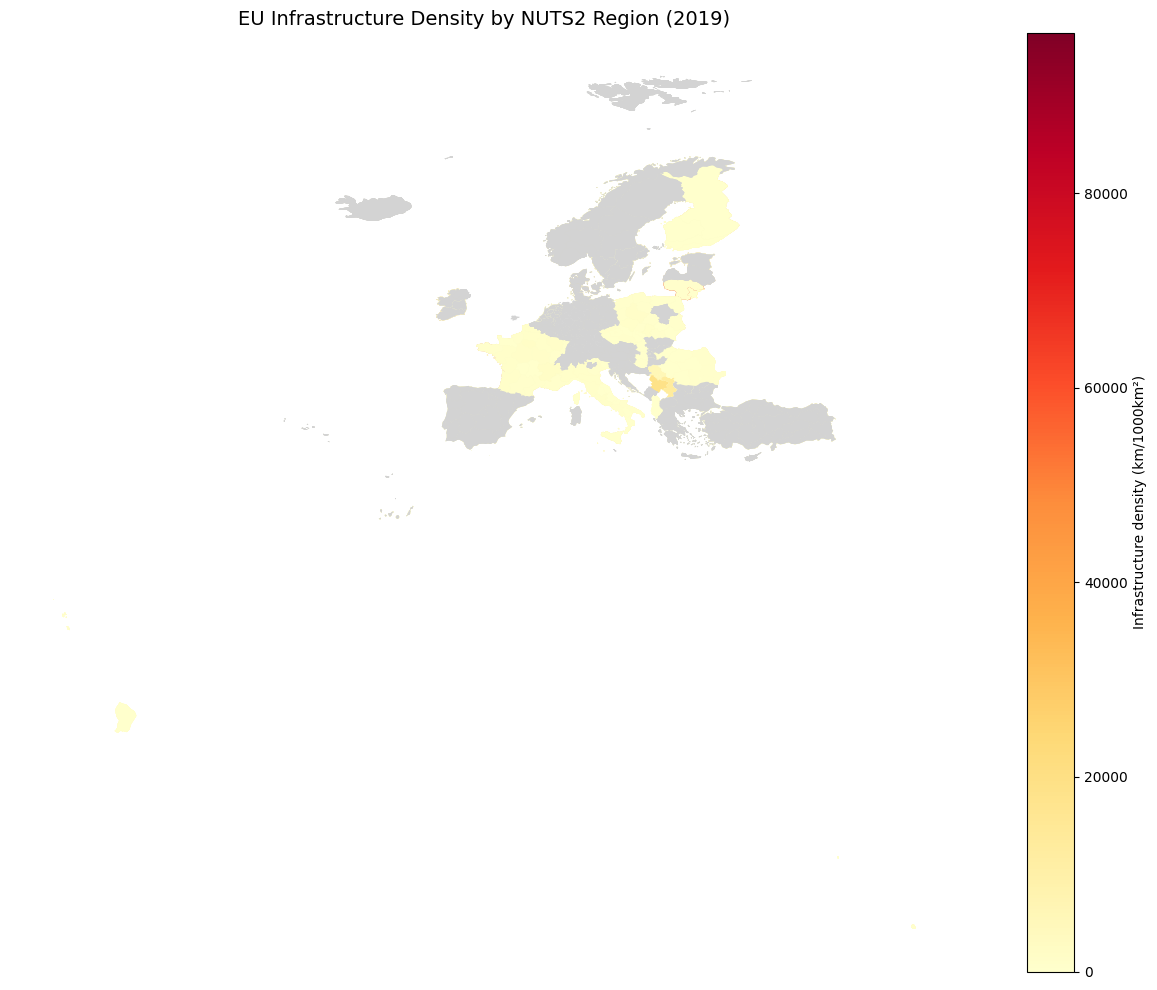


Pipeline complete. `master` dataframe is ready for analysis.
  NUTS_ID         NUTS_NAME  \
0    AT11        Burgenland   
1    AT12  Niederösterreich   
2    AT13              Wien   
3    AT21           Kärnten   
4    AT22        Steiermark   

                                            geometry  year  infra_km  \
0  MULTIPOLYGON (((17.06674 48.11868, 17.1608 48....  1990       NaN   
1  MULTIPOLYGON (((15.75363 48.85218, 16.29009 48...  1990       NaN   
2  MULTIPOLYGON (((16.57804 48.14331, 16.18577 48...  1990       NaN   
3  MULTIPOLYGON (((12.65608 47.0997, 13.07902 47....  1990       NaN   
4  MULTIPOLYGON (((15.37037 47.80928, 15.72657 47...  1990       NaN   

   pop_density country  expenditure_mEUR  mean_elevation_m  elevation_std  \
0          NaN      AT               0.0        262.662323     124.033195   
1          NaN      AT               0.0        462.461304     267.201874   
2          NaN      AT               0.0        210.990005      76.846359   
3         

In [11]:
if __name__ == "__main__":

    # ── Step 1: Load spatial backbone ──────────────────────────
    nuts2 = load_nuts2()

    # ── Step 2: Load time series from Eurostat ──────────────────
    infra  = load_infrastructure()
    pop    = load_population()
    budget = load_budget()

    # ── Step 3: Load static geographic features ─────────────────
    terrain = load_terrain(nuts2)
    water   = load_water_proximity(nuts2)

    # ── Step 4: Explore each source before joining ───────────────
    explore_dataframe(infra,   "Infrastructure (tran_r_net)")
    explore_dataframe(pop,     "Population density (tgs00024)")
    explore_dataframe(budget,  "Public expenditure (gov_10a_exp)")
    explore_dataframe(terrain, "Terrain (SRTM)")
    explore_dataframe(water,   "Water proximity (HydroRIVERS)")

    # ── Step 5: Build master dataframe ───────────────────────────
    master = build_master_df(nuts2, infra, pop, budget, terrain, water)

    # ── Step 6: Quick sanity plot ─────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    master[master['year'] == 2019].plot(
        column='infra_km',
        ax=ax,
        legend=True,
        cmap='YlOrRd',
        missing_kwds={'color': 'lightgrey'},
        legend_kwds={'label': 'Infrastructure density (km/1000km²)'}
    )
    ax.set_title('EU Infrastructure Density by NUTS2 Region (2019)', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('./data/sanity_check_map.png', dpi=150)
    plt.show()

    print("\nPipeline complete. `master` dataframe is ready for analysis.")
    print(master.head())

    # ── Step 7: Export master for the dashboard ──────────────────
    master.drop(columns="geometry").to_csv("./data/master.csv", index=False)
    print("Exported master to ./data/master.csv")

In [12]:
master.isnull().mean().mul(100).round(2).astype(str) + '%'

NUTS_ID               0.0%
NUTS_NAME            8.46%
geometry             8.46%
year                  0.0%
infra_km            48.58%
pop_density         69.66%
country               0.0%
expenditure_mEUR    15.67%
mean_elevation_m     8.46%
elevation_std        8.46%
dist_to_river_km     8.46%
dtype: str

In [13]:
master

,NUTS_ID,NUTS_NAME,geometry,year,infra_km,pop_density,country,expenditure_mEUR,mean_elevation_m,elevation_std,dist_to_river_km
0,AT11,Burgenland,"MULTIPOLYGON (((17.06674 48.11868, 17.1608 48....",1990,NaN,NaN,AT,0.0,262.662323,124.033195,36.201865
1,AT12,Niederösterreich,"MULTIPOLYGON (((15.75363 48.85218, 16.29009 48...",1990,NaN,NaN,AT,0.0,462.461304,267.201874,11.730097
2,AT13,Wien,"MULTIPOLYGON (((16.57804 48.14331, 16.18577 48...",1990,NaN,NaN,AT,0.0,210.990005,76.846359,1.865639
3,AT21,Kärnten,"MULTIPOLYGON (((12.65608 47.0997, 13.07902 47....",1990,NaN,NaN,AT,0.0,1166.613770,565.791443,17.199728
4,AT22,Steiermark,"MULTIPOLYGON (((15.37037 47.80928, 15.72657 47...",1990,NaN,NaN,AT,0.0,972.048340,490.179382,23.061245
...,...,...,...,...,...,...,...,...,...,...,...
83960,TRC1,"Gaziantep, Adıyaman, Kilis","MULTIPOLYGON (((38.33176 38.19605, 38.84173 38...",2024,77.0,194.0,TR,NaN,826.299133,347.245758,10.320082
83961,TRC2,"Şanlıurfa, Diyarbakır","MULTIPOLYGON (((41.30475 38.66466, 41.38055 38...",2024,0.0,119.3,TR,NaN,746.815491,277.477905,59.146372
83962,TRC3,"Mardin, Batman, Şırnak, Siirt","MULTIPOLYGON (((41.7023 38.24654, 41.97949 38....",2024,0.0,95.5,TR,NaN,1076.630737,546.181824,13.206447
83963,UKN0,Northern Ireland,"MULTIPOLYGON (((-5.97653 55.0566, -5.96388 54....",2024,NaN,NaN,UK,NaN,117.864365,92.556137,13.093844


---

## 6. Analysis (to be completed by the team)

Add your query functions here. Each one should:
- Have a docstring with Input / Output
- Include a markdown cell explaining what the indicator means and how to interpret it
- Be called from a `main` block at the end

### Query 1 - Grouping [1pt] (FAIT)
*Example: which NUTS2 regions have the highest infrastructure density per unit of public expenditure?*

### Query 2 - Pattern Mining [2pt]
*Example: frequent itemsets of (terrain_bucket, water_bucket, budget_bucket) → infrastructure level clusters*

### Query 3 - Spatial [2pt]
*Example: spatial clustering (DBSCAN or KMeans on geography) of under/over-infrastructure regions relative to geographic difficulty*

### Query 4 - Temporal [2pt]
*Example: time series forecasting of infrastructure density using lag features (infra_t-1, budget_t-1, pop_t-1)*

### Query 1 — Infrastructure efficiency (Grouping) [1pt]

**Indicator**: `efficiency = infra_km / expenditure_mEUR`

- **How it's calculated**: for a given year, regions are grouped by `NUTS_ID`
  (using `groupby().agg()`), then their road/rail infrastructure density
  (`infra_km`) is divided by their public transport expenditure
  (`expenditure_mEUR`).
- **What it represents**: how many kilometres of infrastructure exist per
  million EUR of public spending — a proxy for "infrastructure return on
  public investment".
- **How to interpret it**: a high value means the region already has an
  extensive network relative to current spending (mature network, less
  marginal investment needed). A low value can indicate a region investing
  heavily relative to its existing network — e.g. catching up, or facing
  higher construction costs due to difficult terrain.
- The chart below shows the **top 15 regions** by this ratio, coloured by
  country.

In [14]:
# ─────────────────────────────────────────────
# Function: query1_infrastructure_efficiency
# Input:  df (master dataframe), year (int, default 2021), top_n (int, default 15)
# Output: Plotly Figure — horizontal bar chart of top_n regions by efficiency
# ─────────────────────────────────────────────
def query1_infrastructure_efficiency(df, year=2021, top_n=15):
    sub = df[df['year'] == year].copy()

    # Group by region, averaging in case of duplicate rows
    grouped = sub.groupby(['NUTS_ID', 'NUTS_NAME', 'country'], as_index=False).agg(
        infra_km=('infra_km', 'mean'),
        expenditure_mEUR=('expenditure_mEUR', 'mean'),
    )

    # Avoid division by zero / negative spending
    grouped = grouped[grouped['expenditure_mEUR'] > 0]
    grouped['efficiency'] = grouped['infra_km'] / grouped['expenditure_mEUR']

    top = grouped.sort_values('efficiency', ascending=False).head(top_n)

    fig = px.bar(
        top.sort_values('efficiency'),
        x='efficiency',
        y='NUTS_ID',
        orientation='h',
        color='country',
        labels={
            'efficiency': 'km of infrastructure per million EUR spent',
            'NUTS_ID': 'NUTS2 region',
            'country': 'Country',
        },
        title=f'Top {top_n} NUTS2 regions by infrastructure efficiency ({year})',
    )
    fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
    return fig

In [15]:
# Call Query 1 on the master dataframe and display the result
fig_q1 = query1_infrastructure_efficiency(master, year=2021, top_n=15)
fig_q1.show()

### Query 2 — Pattern Mining (Frequent itemsets) [2pt]

**Indicator**: the combinations of region characteristics that occur most
often together (frequent itemsets).

- **How it's calculated**: each NUTS2 region (averaged over **2015–2022**, the
  best-covered years) is described by four labels — terrain, water, budget and
  infrastructure — each cut into **low / mid / high tertiles** with `pd.qcut`.
  A region is then a *basket* of items, e.g. `terrain=mid, water=far,
  budget=low, infra=low`. The **Apriori** algorithm (`mlxtend`,
  `min_support=0.10`) finds the combinations of labels that appear together in
  many regions; we keep the combinations of at least two labels.
- **What the metric means**: the only metric is **support** = the share of
  regions that contain the combination. A support of 0.17 means 17 % of all
  regions share that exact pair of characteristics.
- **How to interpret it**: the top bars are the dominant regional profiles in
  Europe. Combinations such as *budget=low + infra=low* or *budget=high +
  infra=high* show that public spending and infrastructure density go together,
  while *infra=low + terrain=mid* shows that harder terrain coincides with
  sparser networks — exactly the relationship this project investigates.

- **Variables**:
  - `terrain`: Elevation
  - `budget`: Public transport spending
  - `infra`: Road/rail density
  - `water`: Distance to the nearest river

In [16]:
# ─────────────────────────────────────────────
# Function: query2_pattern_mining
# Input:  df (master dataframe), year_min/year_max (averaging window),
#         min_support (Apriori threshold), top_n (combinations to display)
# Output: Plotly Figure — horizontal bar chart of the most frequent
#         combinations of region characteristics (support only)
# ─────────────────────────────────────────────
def query2_pattern_mining(df, year_min=2015, year_max=2022, min_support=0.10, top_n=10):
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori
    
    sub = df[df['year'].between(year_min, year_max)].copy()

    # One row per region: average over the well-covered recent years
    cols = ["mean_elevation_m", "dist_to_river_km", "expenditure_mEUR", "infra_km"]
    reg = sub.groupby("NUTS_ID")[cols].mean().dropna().reset_index()

    # Turn each continuous variable into a low / mid / high label (= an item)
    def buckets(s, name):
        return pd.qcut(s, 3, labels=[f"{name}=low", f"{name}=mid", f"{name}=high"])

    reg["terrain"] = buckets(reg["mean_elevation_m"], "terrain")  
    reg["budget"]  = buckets(reg["expenditure_mEUR"], "budget")   
    reg["infra"]   = buckets(reg["infra_km"], "infra")            
    reg["water"]   = pd.qcut(reg["dist_to_river_km"], 3,          
                             labels=["water=near", "water=mid", "water=far"])

    # Build the basket matrix and mine frequent itemsets with Apriori
    baskets = reg[["terrain", "water", "budget", "infra"]].astype(str).values.tolist()
    te = TransactionEncoder()
    onehot = pd.DataFrame(te.fit_transform(baskets), columns=te.columns_)
    itemsets = apriori(onehot, min_support=min_support, use_colnames=True)

    # Keep the real "patterns": combinations of at least 2 items, ranked by support
    itemsets["size"] = itemsets["itemsets"].apply(len)
    itemsets["combination"] = itemsets["itemsets"].apply(lambda s: " + ".join(sorted(s)))
    top = (itemsets[itemsets["size"] >= 2]
           .sort_values("support", ascending=False).head(top_n))

    # Visualise: most frequent combinations, ranked by support
    fig = px.bar(
        top.sort_values("support"),
        x="support", y="combination", orientation="h",
        color="support", color_continuous_scale="Reds",
        labels={"support": "Support (share of regions)", "combination": "Frequent combination"},
        title="Query 2 - Most frequent combinations of region characteristics",
    )
    fig.update_layout(height=500, yaxis={"categoryorder": "total ascending"})
    return fig

In [17]:
# Call Query 2 on the master dataframe and display the result
fig_q2 = query2_pattern_mining(master)
fig_q2.show()

**Interpretation:**

The chart shows the combinations of regional characteristics that most frequently occur together across regions, measured by support (the share of regions where the combination appears). The values are fairly low and tightly clustered (~0.13 to 0.17), which means no single combination really dominates: even the most frequent one only occurs in about 17% of regions.

The two strongest pairs are budget=low + infra=low (~0.17) and budget=mid + infra=mid (~0.16). This is intuitive and coherent: budget level and infrastructure level "go hand in hand" — regions tend to have infrastructure that matches their financial means.

The remaining combinations mostly mix infrastructure, terrain, and water proximity, with supports very close to one another (~0.13–0.14). This weak separation suggests these associations are softer / less structuring: there's a slight tendency (e.g. infra=low ↔ terrain=mid), but nothing as pronounced as the budget–infrastructure coupling.